<a href="https://colab.research.google.com/github/Irving1409/MVP-Sprint-Machine-Learnig---PUC-Rio/blob/main/MVP_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Irving Lui de Souza Caetano_  
**Matrícula:** _4052026000483_  
**Data:** _09/06/2026_  
**Dataset:** _APS Failure at Scania Trucks | UCI_  
**Tipo de problema:** _Classificação_

---



# 1. Definição do problema
Desenvolver um modelo de classificação capaz de prever a ocorrência de falhas em equipamentos industriais a partir de dados operacionais coletados por sensores, auxiliando a manutenção preditiva e reduzindo paradas não planejadas na produção.
## 1.1 Descrição do problema
A gestão de ativos e a manutenção de equipamentos industriais são pilares estratégicos para garantir a continuidade dos processos produtivos e a otimização dos custos operacionais. Falhas imprevistas no maquinário geram gargalos severos, como paradas não planejadas na linha de produção, atrasos na cadeia de suprimentos, elevação dos custos com manutenção corretiva e aumento dos riscos á segurança operacional.

Diante desse cenário, este projeto propõe o desenvolvimento de um modelo de classificação supervisionada para predizer a ocorrência de falhas em equipamentos industriais a partir de variáveis operacionais contínuas coletadas via sensores. O objetivo central é mapear padrões de comportamento anômalos nos dados históricos para antecipar falhas iminentes, viabilizando intervenções preventivas assertivas.

A aplicação de algoritmos de Machine Learning voltados à manutenção preditiva visa maximizar a confiabilidade e a disponibilidade dos ativos. Espera-se, com isso, mitigar custos operacionais e fundamentar a tomada de decisão em evidências baseadas em dados, promovendo a eficiência e a sustentabilidade dos processos industriais.

## 1.2 Objetivo do MVP

O objetivo deste MVP é investigar a aplicação de técnicas de Machine Learning em um problema de manutenção preditiva, por meio da construção e avaliação de modelos de classificação, comparando seus resultados com uma abordagem baseline e analisando suas limitações.

## 1.3 Tipo de problema

**Tipo escolhido:** _Classificação_  
**Justificativa:** _O problema delineia-se como uma tarefa de classificação supervisionada, cujo propósito é predizer o estado operacional de um ativo — categorizado de forma binária entre a operação normal e a iminência de falha. A partir de variáveis históricas coletadas via sensores, o algoritmo visa mapear padrões multidimensionais que permitam discriminar e rotular corretamente novas observações analíticas._

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. _As variáveis operacionais coletadas pelos sensores apresentam padrões e comportamentos distintos entre equipamentos em operação normal e equipamentos com falha, permitindo sua utilização para fins preditivos._

2. _Modelos avançados de aprendizado de máquina serão capazes de capturar interações complexas e não-lineares entre os sensores de forma mais eficaz do que uma abordagem baseline baseada em regras heurísticas ou regressão logística simples._

3. _O conjunto de dados possui quantidade e qualidade suficientes para o treinamento de modelos capazes de generalizar adequadamente para novos dados._

**Critérios de sucesso:**
- Métrica principal: _F1-Score_

_Justificativa técnica: Dado que falhas industriais são eventos raros, os dados são altamente desbalanceados. A Acurácia seria uma métrica enganosa aqui. O Recall garante que estamos detectando as falhas, enquanto a Precisão garante que não estamos gerando alarmes falsos em excesso. O F1-Score balanceia ambos._
- Resultado mínimo esperado: _O modelo candidato deve apresentar um ganho de performance de, no mínimo, 15% no F1-Score em relação ao modelo baseline, atingindo um F1-Score mínimo absoluto de 0.80 (80%) na base de teste._

- Restrição prática: _O modelo deve apresentar baixo custo computacional e tempo de treinamento compatível com o ambiente disponível para execução dos experimentos, mantendo desempenho preditivo satisfatório._


# 2. Ambiente, bibliotecas e reprodutibilidade


In [36]:
# Manipulação de dados
import pandas as pd
import numpy as np
import os


# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Modelos
import sklearn
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Configuração visual
sns.set_theme(style="whitegrid")

print("Versão do Pandas:", pd.__version__)
print("Versão do NumPy:", np.__version__)
print("Versão do Scikit-learn:", sklearn.__version__)


Versão do Pandas: 2.2.2
Versão do NumPy: 2.0.2
Versão do Scikit-learn: 1.6.1


## 2.1 Funções auxiliares


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_classification(y_true, y_pred):

    #Calcula as principais métricas de avaliação para classificação.

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label='pos'),
        "Recall": recall_score(y_true, y_pred, pos_label='pos'),
        "F1-Score": f1_score(y_true, y_pred, pos_label='pos')
    }

def show_results_table(results):

    #Exibe os resultados em formato tabular.

    return pd.DataFrame(results).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados
O dataset utilizado neste MVP foi o **APS Failure at Scania Trucks**, disponibilizado pela **UCI Machine Learning Repository**.

A base foi escolhida por representar um problema real de manutenção preditiva, com dados relacionados a falhas no sistema pneumático APS de caminhões Scania. Trata-se de um problema de classificação binária, em que a variável alvo `class` indica se a falha está relacionada ao sistema APS (`pos`) ou não (`neg`).

O dataset foi carregado diretamente por URL pública, sem necessidade de upload manual ou arquivos locais, garantindo maior reprodutibilidade. As variáveis preditoras foram anonimizadas por questões de confidencialidade, o que limita a interpretação individual dos atributos, mas não impede sua utilização para modelagem preditiva.


## 3.2 Carga dos dados

In [38]:
# === Carga dos dados ===

# URLs públicas do dataset APS Failure at Scania Trucks - UCI
url_train = "https://archive.ics.uci.edu/ml/machine-learning-databases/00421/aps_failure_training_set.csv"
url_test = "https://archive.ics.uci.edu/ml/machine-learning-databases/00421/aps_failure_test_set.csv"

# Carregamento dos dados
df_train = pd.read_csv(url_train, skiprows=20, na_values="na")
df_test = pd.read_csv(url_test, skiprows=20, na_values="na")

# Visualização inicial
df_train.head()


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


## 3.3 Visão geral do dataset


In [39]:
print("\nTipos de dados:")
display(df_train.dtypes.to_frame("tipo"))

# Quantidade de linhas e colunas
print(f'Número de linhas: {df_train.shape[0]}')
print(f'Número de colunas: {df_train.shape[1]}')


Tipos de dados:


,tipo
class,object
aa_000,int64
ab_000,float64
ac_000,float64
ad_000,float64
...,...
ee_007,float64
ee_008,float64
ee_009,float64
ef_000,float64


Número de linhas: 60000
Número de colunas: 171


### Estatísticas descritivas

As estatísticas descritivas fornecem uma visão geral do comportamento das variáveis numéricas presentes no conjunto de dados. Essa análise permite identificar medidas de tendência central, dispersão e amplitude, além de fornecer indícios sobre a existência de valores extremos (outliers) e possíveis assimetrias nas distribuições dos atributos.

In [40]:
df_train.describe()

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
count,6.000000e+04,13671.000000,5.666500e+04,4.513900e+04,57500.000000,57500.000000,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,...,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,57276.000000,57277.000000
mean,5.933650e+04,0.713189,3.560143e+08,1.906206e+05,6.819130,11.006817,2.216364e+02,9.757223e+02,8.606015e+03,8.859128e+04,...,4.454897e+05,2.111264e+05,4.457343e+05,3.939462e+05,3.330582e+05,3.462714e+05,1.387300e+05,8.388915e+03,0.090579,0.212756
std,1.454301e+05,3.478962,7.948749e+08,4.040441e+07,161.543373,209.792592,2.047846e+04,3.420053e+04,1.503220e+05,7.617312e+05,...,1.155540e+06,5.433188e+05,1.168314e+06,1.121044e+06,1.069160e+06,1.728056e+06,4.495100e+05,4.747043e+04,4.368855,8.830641
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,8.340000e+02,0.000000,1.600000e+01,2.400000e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.936000e+03,1.166000e+03,2.700000e+03,3.584000e+03,5.120000e+02,1.100000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,3.077600e+04,0.000000,1.520000e+02,1.260000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.337960e+05,1.120860e+05,2.215180e+05,1.899880e+05,9.243200e+04,4.109800e+04,3.812000e+03,0.000000e+00,0.000000,0.000000
75%,4.866800e+04,0.000000,9.640000e+02,4.300000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.383960e+05,2.182320e+05,4.666140e+05,4.032220e+05,2.750940e+05,1.678140e+05,1.397240e+05,2.028000e+03,0.000000,0.000000
max,2.746564e+06,204.000000,2.130707e+09,8.584298e+09,21050.000000,20070.000000,3.376892e+06,4.109372e+06,1.055286e+07,6.340207e+07,...,7.793393e+07,3.775839e+07,9.715238e+07,5.743524e+07,3.160781e+07,1.195801e+08,1.926740e+07,3.810078e+06,482.000000,1146.000000


**Interpretação:**

A tabela de estatísticas descritivas apresenta informações como quantidade de valores não nulos (`count`), média (`mean`), desvio padrão (`std`), valores mínimo e máximo (`min` e `max`), além dos quartis (25%, 50% e 75%) de cada variável numérica.

Observa-se que algumas variáveis possuem quantidade de observações inferior a 60.000 registros, confirmando a presença de valores ausentes identificada anteriormente. Além disso, em diversos atributos a diferença entre os valores máximos e os quartis superiores é bastante elevada, indicando a existência de valores extremos (outliers) e distribuições assimétricas.

Essas características são comuns em problemas de manutenção preditiva, nos quais determinados sensores podem registrar valores significativamente diferentes durante eventos de falha. Por esse motivo, a identificação dos outliers será aprofundada na próxima etapa da análise exploratória, antes da definição da estratégia de pré-processamento dos dados.

### Análise dos valores ausentes

A identificação dos valores ausentes é uma etapa importante da análise exploratória, pois permite avaliar a qualidade do conjunto de dados e orientar a estratégia de pré-processamento. Nesta análise são apresentadas a quantidade e o percentual de valores ausentes em cada atributo, permitindo identificar as variáveis mais afetadas pela ausência de informações.

In [41]:
print("\nValores ausentes por coluna:")

# Quantidade de valores ausentes
missing_count = df_train.isnull().sum()

# Percentual de valores ausentes
missing_percent = (df_train.isnull().mean() * 100)

# Junta as duas informações
missing_summary = pd.concat(
    [missing_count, missing_percent],
    axis=1
)

missing_summary.columns = [
    "Quantidade",
    "Percentual (%)"
]

# Mantém apenas colunas com valores ausentes
missing_summary = missing_summary[
    missing_summary["Quantidade"] > 0
]

# Ordena da maior para a menor quantidade
missing_summary = missing_summary.sort_values(
    by="Quantidade",
    ascending=False
)

display(missing_summary.head(20).round(2))



Valores ausentes por coluna:


,Quantidade,Percentual (%)
br_000,49264,82.11
bq_000,48722,81.20
bp_000,47740,79.57
bo_000,46333,77.22
cr_000,46329,77.22
ab_000,46329,77.22
bn_000,44009,73.35
bm_000,39549,65.92
bl_000,27277,45.46
bk_000,23034,38.39


**Interpretação:**

A análise revelou que a maioria das variáveis do conjunto de dados apresenta valores ausentes, embora em diferentes proporções. Observa-se que algumas colunas possuem mais de 80% de valores ausentes, enquanto outras apresentam poucas ocorrências desse problema.

Esse comportamento indica que uma estratégia única de tratamento pode não ser adequada para todas as variáveis. Durante a etapa de preparação dos dados, será avaliada a utilização de técnicas de imputação e, quando necessário, a remoção de atributos com elevada proporção de valores ausentes, buscando preservar a qualidade das informações utilizadas na construção dos modelos de Machine Learning.

In [42]:
print("\nDuplicatas:", df_train.duplicated().sum())



Duplicatas: 0


In [43]:
df_train['class'].value_counts()

,count
class,
neg,59000
pos,1000


### Análise das variáveis

A inspeção inicial do conjunto de dados não identificou colunas de identificação (ID), datas ou atributos que representem vazamento de informação (*data leakage*). As variáveis preditoras correspondem a medições operacionais anonimizadas provenientes dos sensores do sistema APS, enquanto a coluna `class` representa a variável alvo do problema de classificação.

Nesta etapa, não foram identificadas variáveis que devam ser removidas por questões de identificação ou temporalidade. A necessidade de exclusão de atributos será avaliada posteriormente durante a etapa de preparação dos dados, considerando critérios como elevada proporção de valores ausentes, baixa variabilidade ou baixa relevância para a modelagem.

## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---------|------|-----------|------------------------|-------------|
| class | Categórica | Variável alvo que indica ocorrência de falha no sistema APS (`pos`) ou ausência de falha (`neg`). | Alvo | Classe que será prevista pelo modelo. |
| aa_000 | Numérica | Medição de um sensor do sistema do caminhão. | Sim | Variável preditora. |
| ab_000 | Numérica | Medição de um sensor do sistema do caminhão. | Sim | Possui valores ausentes. |
| ac_000 | Numérica | Medição operacional do veículo. | Sim | Variável contínua. |
| ad_000 | Numérica | Medição operacional do veículo. | Sim | Possui valores ausentes. |
| ae_000 | Numérica | Medição de sensor utilizada para caracterizar o estado do equipamento. | Sim | Variável contínua. |
| af_000 | Numérica | Medição de sensor do sistema monitorado. | Sim | Variável contínua. |

> **Observação:** O dataset **APS Failure at Scania Trucks** possui **170 variáveis preditoras** anonimizadas (`aa_000` a `ee_009`) e uma variável alvo (`class`). As variáveis foram anonimizadas pela Scania para preservar informações confidenciais sobre o sistema pneumático (APS). Por esse motivo, este dicionário apresenta apenas alguns atributos representativos, suficientes para descrever a estrutura da base e o problema de classificação abordado neste MVP.

# 4. Análise exploratória dos dados


In [44]:
# Ajuste estas variáveis conforme seu problema.
TARGET = "class"
PROBLEM_TYPE = "classificacao"

print("Distribuição da variável alvo")
display(df_train[TARGET].value_counts().to_frame("Quantidade"))

display(
    (df_train[TARGET].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("Percentual (%)")
)


Distribuição da variável alvo


,Quantidade
class,
neg,59000
pos,1000


,Percentual (%)
class,
neg,98.33
pos,1.67


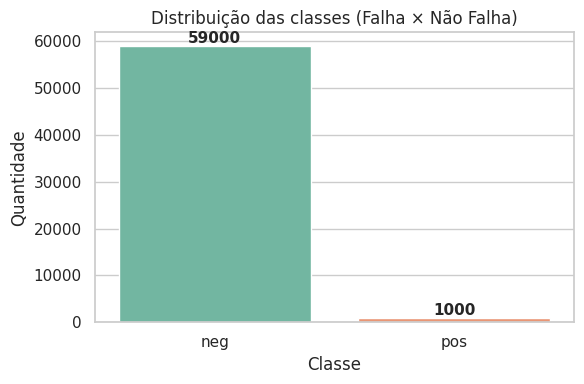

In [45]:
# Contagem das classes
counts = df_train["class"].value_counts()

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df_train,
    x="class",
    hue="class",
    palette="Set2",
    legend=False
)

# Adiciona apenas a quantidade sobre cada barra
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Distribuição das classes (Falha × Não Falha)")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.tight_layout()

plt.show()

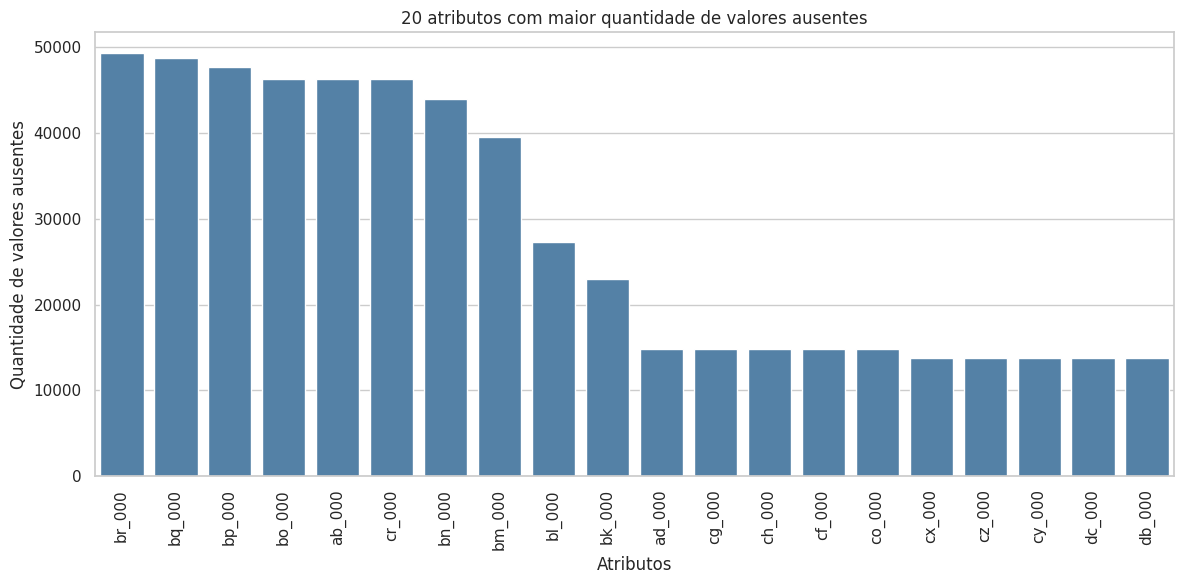

,% Valores Ausentes
br_000,82.11
bq_000,81.20
bp_000,79.57
bo_000,77.22
ab_000,77.22
cr_000,77.22
bn_000,73.35
bm_000,65.92
bl_000,45.46
bk_000,38.39


In [46]:
# Quantidade de valores ausentes por coluna
missing = (
    df_train.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_count = missing.head(20)
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing_count.index,
    y=missing_count.values,
    color="steelblue"
)

plt.xticks(rotation=90)

plt.title("20 atributos com maior quantidade de valores ausentes")

plt.xlabel("Atributos")

plt.ylabel("Quantidade de valores ausentes")

plt.tight_layout()

plt.show()

missing_percent = (
    df_train.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent.head(20).round(2).to_frame("% Valores Ausentes")

**Interpretação:**

A distribuição da variável alvo evidencia um forte desbalanceamento entre as classes. Dos **60.000** registros do conjunto de treinamento, **59.000 (98,33%)** pertencem à classe **neg**, enquanto apenas **1.000 (1,67%)** pertencem à classe **pos**.

Esse comportamento é esperado em problemas de manutenção preditiva, nos quais falhas em equipamentos são eventos pouco frequentes. Em função desse desbalanceamento, a utilização da **acurácia** como principal métrica pode levar a interpretações equivocadas, uma vez que um modelo pode obter elevada acurácia classificando a maioria das observações como pertencentes à classe majoritária.

Dessa forma, optou-se pela utilização do **F1-Score** como principal métrica de avaliação, por equilibrar (*Precision*) e (*Recall*), fornecendo uma medida mais representativa da capacidade do modelo em identificar corretamente os eventos de falha.

### 4.1 Identificação de outliers

Nesta etapa são analisadas algumas variáveis numéricas representativas por meio de boxplots, com o objetivo de identificar a presença de valores extremos (outliers). Essa análise auxilia na compreensão da distribuição dos dados e subsidia futuras decisões sobre tratamento ou manutenção desses valores durante o pré-processamento.

Considerando que o conjunto de dados possui **170 atributos numéricos**, foi selecionado um subconjunto de variáveis representativas para ilustrar a presença de valores extremos, tornando a análise exploratória mais objetiva e facilitando a interpretação dos resultados.

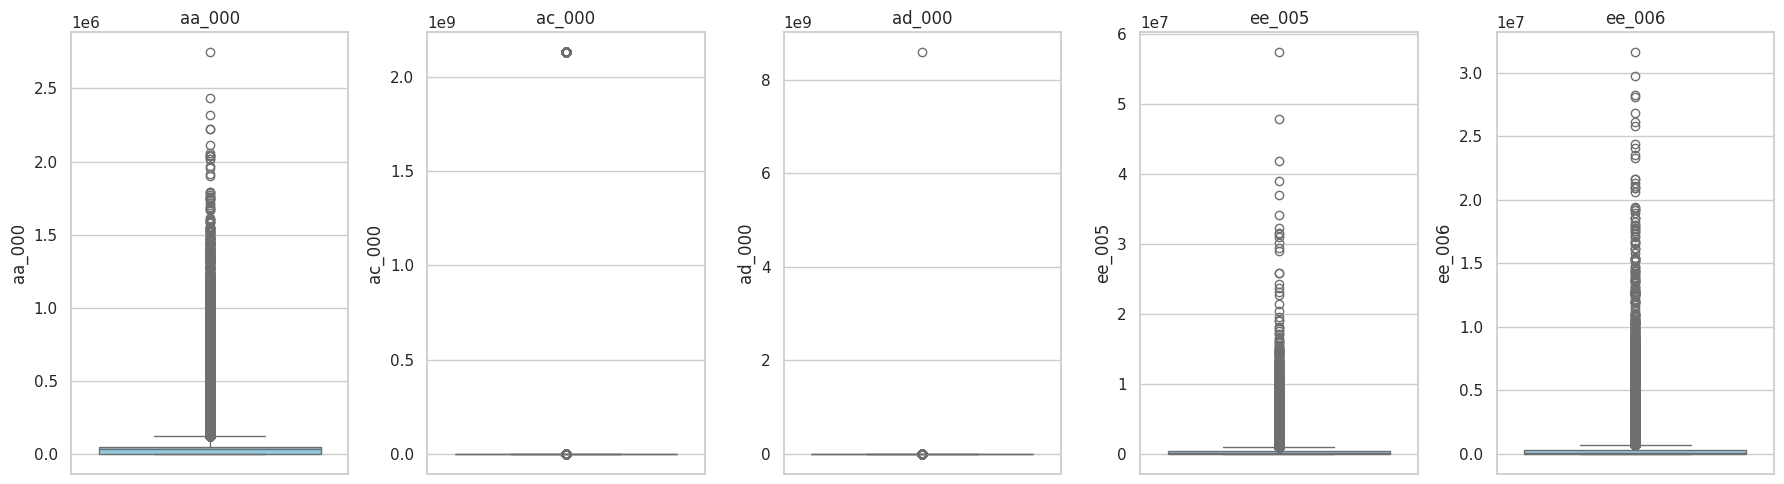

In [47]:
# Variáveis selecionadas para análise
features = ["aa_000", "ac_000", "ad_000", "ee_005", "ee_006"]

fig, axes = plt.subplots(1, len(features), figsize=(18,5))

for i, feature in enumerate(features):

    sns.boxplot(
        y=df_train[feature],
        ax=axes[i],
        color="skyblue"
    )

    axes[i].set_title(feature)

plt.tight_layout()

plt.show()

### Interpretação

Os boxplots evidenciam a presença de valores extremos (outliers) em todas as variáveis analisadas. Esses valores aparecem como observações isoladas acima dos limites superiores da distribuição, indicando que determinados registros apresentam medições significativamente superiores à maioria dos dados.

Em problemas de manutenção preditiva, a presença de outliers não deve ser interpretada automaticamente como erro ou ruído. Esses valores podem representar condições reais de operação anormal ou o comportamento de equipamentos próximos de uma falha. Dessa forma, a opção foi apenas por identificá-los, deixando a decisão sobre eventual tratamento para a fase de preparação dos dados, considerando seu impacto no desempenho dos modelos de Machine Learning.

### 4.2 Relação entre as variáveis e a variável alvo

Nesta etapa é analisada a relação entre algumas variáveis numéricas representativas e a variável alvo (`class`). O objetivo é verificar se existem diferenças no comportamento das medições dos sensores entre equipamentos que apresentaram falha (`pos`) e aqueles que operaram normalmente (`neg`), identificando possíveis padrões que possam contribuir para a discriminação das classes durante a modelagem.

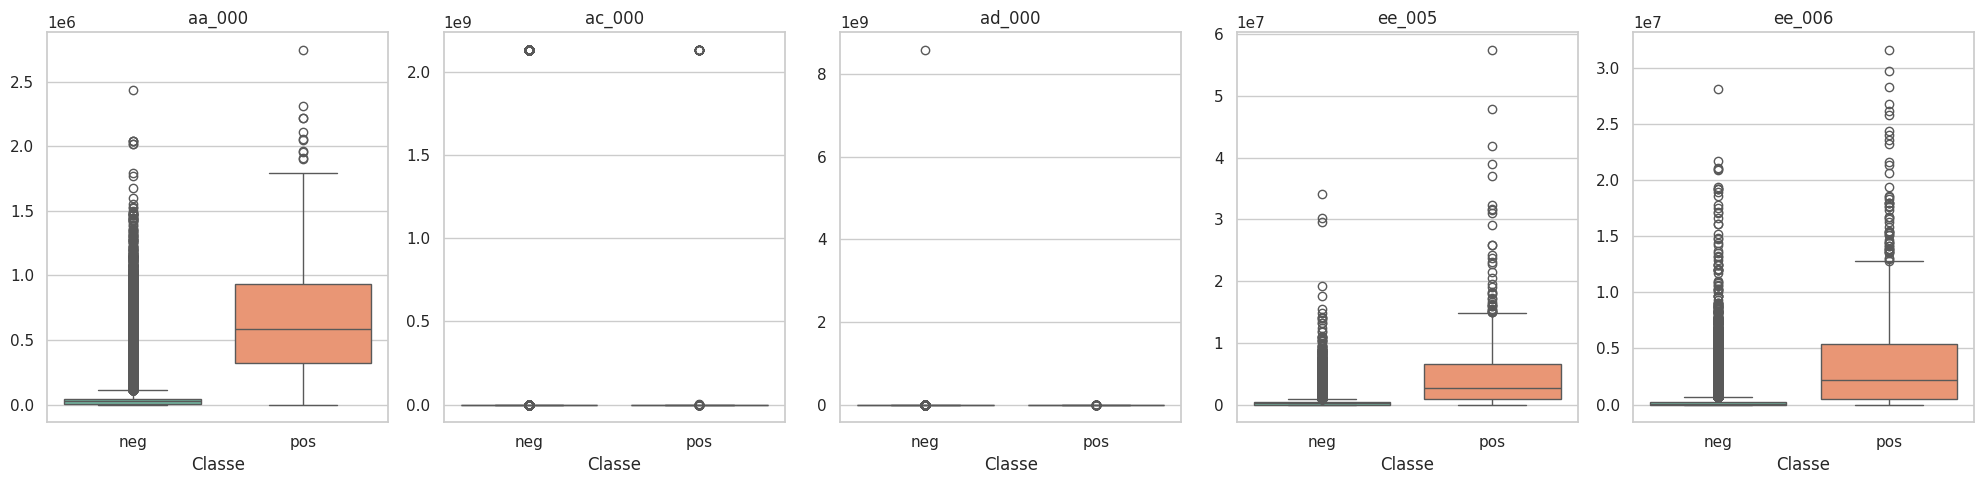

In [48]:
# Variáveis selecionadas
features = ["aa_000", "ac_000", "ad_000", "ee_005", "ee_006"]

fig, axes = plt.subplots(1, len(features), figsize=(20,5))

for i, feature in enumerate(features):

    sns.boxplot(
        data=df_train,
        x="class",
        y=feature,
        ax=axes[i],
        palette="Set2",
        hue="class",
        legend=False
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("Classe")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

### Interpretação

Os boxplots permitiram comparar a distribuição de algumas variáveis representativas entre as classes **neg** (sem falha) e **pos** (com falha). Observa-se que determinadas variáveis, como **aa_000**, **ee_005** e **ee_006**, apresentam diferenças mais evidentes entre as classes, com medianas mais elevadas e maior dispersão para os registros classificados como falha.

Por outro lado, as variáveis **ac_000** e **ad_000** apresentam distribuições bastante semelhantes entre as duas classes, sugerindo menor capacidade discriminatória quando analisadas isoladamente.

Esses resultados indicam que algumas variáveis possuem maior potencial para contribuir com a identificação de falhas, enquanto outras podem exercer influência reduzida individualmente. Entretanto, como os modelos de Machine Learning analisam simultaneamente todas as variáveis, atributos que isoladamente parecem pouco informativos ainda podem contribuir para o desempenho final do modelo quando combinados com os demais.

### 4.3 Hipóteses geradas pela análise exploratória

A análise exploratória permitiu compreender as principais características do conjunto de dados e levantar hipóteses que orientarão as próximas etapas do projeto.

Os resultados evidenciaram um forte desbalanceamento entre as classes, indicando que métricas como acurácia não são suficientes para avaliar o desempenho dos modelos. Dessa forma, o F1-Score será adotado como principal métrica de avaliação, por equilibrar precisão e revocação na identificação dos eventos de falha.

Também foi identificada uma elevada quantidade de valores ausentes em diversos atributos, sugerindo a necessidade de aplicação de técnicas adequadas de tratamento durante o pré-processamento, evitando perdas excessivas de informação.

A análise dos boxplots revelou a presença de valores extremos (outliers) em diferentes variáveis. Considerando o contexto de manutenção preditiva, esses valores podem representar condições reais de operação anormal e, portanto, não serão removidos automaticamente, sendo sua influência avaliada durante a modelagem.

Por fim, a comparação entre algumas variáveis e a variável alvo mostrou que determinados atributos apresentam diferenças relevantes entre equipamentos com e sem falha, indicando que essas informações possuem potencial para contribuir na construção de modelos capazes de identificar padrões associados à ocorrência de falhas.

## 4.4 Síntese da análise exploratória

**Síntese:**  
> _A análise exploratória evidenciou que o conjunto de dados apresenta características típicas de um problema de manutenção preditiva. Observou-se um forte desbalanceamento entre as classes, com predominância de registros sem falha, justificando a adoção do F1-Score como principal métrica de avaliação dos modelos._

> _Também foi identificada uma quantidade significativa de valores ausentes em diversos atributos, indicando a necessidade de aplicação de técnicas adequadas de tratamento durante a etapa de pré-processamento. Além disso, verificou-se a presença de valores extremos (outliers), que, devido ao contexto do problema, podem representar condições reais de operação e não serão removidos automaticamente._

> _A comparação entre algumas variáveis e a variável alvo mostrou que determinados atributos apresentam diferenças relevantes entre equipamentos com e sem falha, sugerindo potencial capacidade discriminatória para a tarefa de classificação._

> _Com base nesses resultados, a estratégia de modelagem adotará técnicas apropriadas para lidar com dados desbalanceados, tratamento dos valores ausentes e construção de um pipeline de pré-processamento reprodutível antes do treinamento dos modelos de Machine Learning._


# 5. Preparação dos dados e divisão treino/teste




### 5.1 Definição da variável alvo

A variável **`class`** foi definida como variável alvo (*target*) do problema de classificação. Essa variável indica o estado operacional do sistema APS dos caminhões, assumindo a classe **`neg`** para equipamentos sem falha e **`pos`** para equipamentos com ocorrência de falha.

O objetivo dos modelos de Machine Learning será aprender os padrões presentes nas variáveis preditoras para classificar corretamente novas observações entre essas duas categorias.

In [49]:
# Definição da variável alvo
TARGET = "class"

print(f"Variável alvo: {TARGET}")

Variável alvo: class


### 5.2 Seleção das variáveis preditoras

As variáveis preditoras (*features*) correspondem a todos os atributos utilizados para descrever o estado operacional dos caminhões. Como o conjunto de dados não possui colunas de identificação (ID), datas ou atributos que caracterizem vazamento de informação (*data leakage*), todas as variáveis, exceto a variável alvo (`class`), foram mantidas para a etapa de modelagem.

Dessa forma, o conjunto de atributos preditores será composto pelas 170 variáveis numéricas disponíveis no dataset.

In [50]:
# Seleção das variáveis preditoras
FEATURES = [col for col in df_train.columns if col != TARGET]

In [51]:
# ==========================================
# Resumo da configuração do problema
# ==========================================

print("="*50)
print("CONFIGURAÇÃO DO PROBLEMA")
print("="*50)

print(f"Tipo de problema          : Classificação")
print(f"Variável alvo (Target)    : {TARGET}")
print(f"Número de Features        : {len(FEATURES)}")
print(f"Treinamento               : {df_train.shape[0]} registros")
print(f"Teste                     : {df_test.shape[0]} registros")

print("="*50)

CONFIGURAÇÃO DO PROBLEMA
Tipo de problema          : Classificação
Variável alvo (Target)    : class
Número de Features        : 170
Treinamento               : 60000 registros
Teste                     : 16000 registros


### 5.3 Separação entre Features e Target

Nesta etapa, o conjunto de dados é separado em variáveis preditoras (`X`) e variável alvo (`y`). As variáveis preditoras representam as medições operacionais utilizadas como entrada dos modelos, enquanto a variável alvo representa a classe que será prevista.

Essa separação é necessária para que os algoritmos de Machine Learning aprendam a relação entre os atributos dos caminhões e a ocorrência ou ausência de falha no sistema APS.

In [52]:
# Separação entre variáveis preditoras e variável alvo no conjunto de treinamento
X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET].copy()

# Separação entre variáveis preditoras e variável alvo no conjunto de teste
X_test = df_test[FEATURES].copy()
y_test = df_test[TARGET].copy()

print("Dimensões dos dados:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Dimensões dos dados:
X_train: (60000, 170)
y_train: (60000,)
X_test: (16000, 170)
y_test: (16000,)


### 5.4 Divisão entre treino e teste

Diferentemente de muitos conjuntos de dados utilizados em problemas de classificação, o dataset **APS Failure at Scania Trucks** já disponibiliza os conjuntos de treinamento e teste previamente separados pelos autores da base.

Dessa forma, não foi necessário utilizar a função `train_test_split()` do Scikit-learn, preservando a divisão oficial do dataset. Essa abordagem evita alterações na distribuição original dos dados e garante maior reprodutibilidade dos experimentos realizados.

In [53]:
# Verificação da divisão oficial do dataset

print("Conjunto de treinamento:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nConjunto de teste:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Conjunto de treinamento:
X_train: (60000, 170)
y_train: (60000,)

Conjunto de teste:
X_test: (16000, 170)
y_test: (16000,)


## 5.5 Justificativa da divisão

> _Optou-se por utilizar a divisão oficial disponibilizada pelos autores do dataset **APS Failure at Scania Trucks**, em vez de realizar uma nova separação dos dados._

- **Por que usar holdout, validação cruzada ou divisão temporal?**  
  Neste projeto foi adotada a estratégia **holdout**, utilizando os conjuntos de treinamento e teste já fornecidos pelo dataset. Como não se trata de um problema de séries temporais, não há necessidade de realizar uma divisão baseada no tempo. A validação cruzada poderá ser empregada posteriormente durante o ajuste dos modelos e de seus hiperparâmetros, utilizando apenas o conjunto de treinamento.

- **A proporção treino/teste faz sentido para o tamanho do dataset?**  
  Sim. O conjunto de treinamento possui **60.000 registros (78,95%)** e o conjunto de teste **16.000 registros (21,05%)**, uma proporção muito próxima da divisão tradicional de **80% para treinamento** e **20% para teste**, amplamente utilizada em problemas de Machine Learning.

- **Foi necessário estratificar as classes?**  
  Não. Como a divisão já foi realizada pelos autores do dataset, optou-se por preservá-la. Dessa forma, não foi necessário utilizar o parâmetro `stratify`, que normalmente é empregado quando a divisão é realizada com `train_test_split()`.

- **Como a divisão evita vazamento de dados?**  
  O conjunto de teste permaneceu completamente separado durante a preparação dos dados e será utilizado apenas na avaliação final dos modelos. Assim, todas as etapas de tratamento, treinamento e ajuste serão realizadas utilizando exclusivamente o conjunto de treinamento, reduzindo o risco de vazamento de informações (*data leakage*) e proporcionando uma avaliação mais confiável do desempenho dos modelos.

# 6. Pré-processamento e pipeline

Nesta etapa será construído um pipeline de pré-processamento para tratar os valores ausentes e padronizar as variáveis numéricas antes do treinamento dos modelos.

Como o dataset possui apenas variáveis numéricas como atributos preditores, não será necessário aplicar encoding de variáveis categóricas. A imputação dos valores ausentes será realizada pela mediana, pois essa estratégia é menos sensível a valores extremos, característica identificada durante a análise exploratória.

A padronização será aplicada para colocar as variáveis em escalas comparáveis, especialmente para modelos sensíveis à escala, como a Regressão Logística. Todas as transformações serão ajustadas apenas no conjunto de treinamento e posteriormente aplicadas ao conjunto de teste, reduzindo o risco de vazamento de dados (*data leakage*).

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Identificação das colunas numéricas
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"Número de colunas numéricas: {len(num_cols)}")
print(f"Número de colunas categóricas: 0")

Número de colunas numéricas: 170
Número de colunas categóricas: 0


In [55]:
# Pipeline para variáveis numéricas
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols)
    ],
    remainder="drop"
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['aa_000', 'ab_000', 'ac_000', 'ad_000',
                                  'ae_000', 'af_000', 'ag_000', 'ag_001',
                                  'ag_002', 'ag_003', 'ag_004', 'ag_005',
                                  'ag_006', 'ag_007', 'ag_008', 'ag_009',
                                  'ah_000', 'ai_000', 'aj_000', 'ak_000',
                                  'al_000', 'am_0', 'an_000', 'ao_000',
                                  'ap_000', 'aq_000', 'ar_000', 'as_000',
                                  'at_000', 'au_000', ...])])

## 6.1 Decisões de pré-processamento

> As decisões de pré-processamento foram definidas com base nas características identificadas durante a análise exploratória dos dados.
>
> **Por que utilizar a mediana para imputação dos valores ausentes?**  
> O conjunto de dados apresenta uma quantidade significativa de valores ausentes em diversas variáveis, além da presença de valores extremos (outliers). Optou-se pela utilização da **mediana**, pois essa medida é menos influenciada por valores extremos do que a média, preservando melhor a distribuição original dos dados.
>
> **Por que padronizar os dados?**  
> As variáveis numéricas apresentam escalas bastante diferentes, conforme observado na análise estatística descritiva e nos boxplots. A padronização foi aplicada para que todas as variáveis contribuam de maneira equilibrada para o treinamento dos modelos, principalmente aqueles sensíveis à escala dos dados, como a Regressão Logística.
>
> **Quais variáveis foram removidas e por quê?**  
> Nenhuma variável preditora foi removida nesta etapa. Como o dataset não possui colunas de identificação (ID), datas ou atributos que caracterizem vazamento de informação (*data leakage*), todas as 170 variáveis numéricas foram mantidas para a modelagem.
>
> **Foram criadas novas variáveis?**  
> Não. Nesta etapa não foi realizada engenharia de atributos (*feature engineering*). Foram utilizados apenas os atributos originais disponibilizados pelo dataset, garantindo que todas as informações empregadas no treinamento também estariam disponíveis em um cenário real de previsão.
>
> **Como o pipeline contribui para a modelagem?**  
> O pipeline foi construído para garantir que todas as transformações (imputação dos valores ausentes e padronização) sejam ajustadas exclusivamente com o conjunto de treinamento e posteriormente aplicadas ao conjunto de teste. Essa abordagem reduz o risco de vazamento de dados (*data leakage*), aumenta a reprodutibilidade dos experimentos e segue as boas práticas recomendadas para projetos de Machine Learning.


# 7. Baseline e modelos candidatos

###Modelo Baseline

>Antes de treinar os modelos de Machine Learning, foi definido um modelo de referência (*baseline*) utilizando o `DummyClassifier` do Scikit-Learn.

>Esse modelo não realiza aprendizado sobre os dados. Sua função é estabelecer um desempenho mínimo esperado, permitindo verificar posteriormente se os modelos treinados realmente aprenderam padrões relevantes ou apenas exploraram o desbalanceamento existente na base.

>Neste trabalho foi utilizada a estratégia `most_frequent`, na qual todas as observações são classificadas como pertencentes à classe majoritária (`neg`).

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

# Modelo Baseline
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

### 7.1 Regressão Logística

A Regressão Logística foi utilizada como primeiro modelo de classificação por ser amplamente empregada em problemas de classificação binária. Esse algoritmo estima a probabilidade de uma observação pertencer à classe positiva e, a partir dessa estimativa, realiza a classificação.

Por ser sensível à escala das variáveis, o modelo será treinado utilizando o pipeline de pré-processamento definido anteriormente, garantindo que todas as variáveis numéricas sejam padronizadas antes do treinamento.

In [57]:
from sklearn.linear_model import LogisticRegression

# Pipeline da Regressão Logística
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=SEED,
        max_iter=1000
    ))
])

# Treinamento
logistic_model.fit(X_train, y_train)

# Previsões
y_pred_logistic = logistic_model.predict(X_test)

### 7.2 Árvore de Decisão

A Árvore de Decisão foi utilizada como segundo modelo de classificação por sua capacidade de aprender regras de decisão a partir dos dados, identificando relações não lineares entre as variáveis preditoras e a variável alvo.

Embora esse algoritmo não seja sensível à escala das variáveis, foi mantido o mesmo pipeline de pré-processamento utilizado nos demais modelos, garantindo consistência metodológica e reprodutibilidade durante os experimentos.

In [58]:
from sklearn.tree import DecisionTreeClassifier

# Pipeline da Árvore de Decisão
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=SEED
    ))
])

# Treinamento
tree_model.fit(X_train, y_train)

# Previsões
y_pred_tree = tree_model.predict(X_test)

### 7.3 Random Forest

O modelo Random Forest foi utilizado como terceiro modelo candidato. Esse algoritmo combina múltiplas árvores de decisão, reduzindo a variância do modelo e tornando as previsões mais robustas em comparação com uma única árvore.

A escolha desse modelo é adequada para o problema proposto, pois ele é capaz de capturar relações não lineares e interações complexas entre as variáveis dos sensores, características comuns em problemas de manutenção preditiva.

In [59]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline do Random Forest
forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=SEED,
        n_estimators=100,
        n_jobs=-1
    ))
])

# Treinamento
forest_model.fit(X_train, y_train)

# Previsões
y_pred_forest = forest_model.predict(X_test)

## 7.4 Justificativa dos modelos

> Os modelos utilizados neste trabalho foram selecionados por apresentarem diferentes características de aprendizagem, permitindo comparar abordagens simples e mais robustas para o problema de classificação de falhas no sistema APS dos caminhões Scania.
>
> **O baseline escolhido é coerente?**  
> Sim. O `DummyClassifier` foi utilizado como modelo de referência (*baseline*) utilizando a estratégia `most_frequent`, que sempre prevê a classe majoritária (`neg`). Como o conjunto de dados é fortemente desbalanceado, esse modelo estabelece um desempenho mínimo esperado, permitindo verificar se os modelos de Machine Learning realmente aprendem padrões relevantes além da simples predominância da classe majoritária.
>
> **Os modelos candidatos são adequados ao tipo e ao tamanho dos dados?**  
> Sim. A Regressão Logística, a Árvore de Decisão e a Random Forest são algoritmos amplamente utilizados em problemas de classificação supervisionada. Além de serem adequados para conjuntos de dados com grande quantidade de atributos numéricos, esses modelos apresentam diferentes estratégias de aprendizagem, possibilitando uma comparação consistente de desempenho.
>
> **Algum modelo exige escala, encoding ou tratamento específico?**  
> A Regressão Logística é sensível à escala das variáveis, motivo pelo qual foi aplicada a padronização utilizando o `StandardScaler`. Como todas as variáveis preditoras do dataset são numéricas, não foi necessária a aplicação de técnicas de codificação (*encoding*). O tratamento dos valores ausentes foi realizado por meio da imputação pela mediana, sendo aplicado igualmente a todos os modelos por meio de um pipeline de pré-processamento.
>
> **Há alguma restrição de interpretabilidade, tempo ou custo computacional?**  
> A Regressão Logística apresenta elevada interpretabilidade e baixo custo computacional. A Árvore de Decisão também possui boa interpretabilidade, porém pode apresentar maior tendência ao sobreajuste (*overfitting*). Já a Random Forest possui maior custo computacional por utilizar múltiplas árvores de decisão, mas geralmente oferece melhor capacidade de generalização e maior robustez em problemas de classificação.


# 8. Treinamento e avaliação inicial

### 8.1 Avaliação dos modelos

Após o treinamento dos modelos, foi realizada a avaliação do desempenho utilizando métricas adequadas para problemas de classificação.

Como o conjunto de dados apresenta forte desbalanceamento entre as classes, a análise não será baseada apenas na acurácia. Também serão consideradas as métricas **Accuracy**, **Precision**, **Recall** e **F1-Score**, permitindo uma comparação mais completa entre os modelos treinados.

O F1-Score será utilizado como principal métrica de comparação, pois representa o equilíbrio entre Precision e Recall, sendo mais adequado para problemas em que a classe positiva é minoritária.

In [60]:
# Avaliação dos modelos

results = {
    "Baseline": evaluate_classification(
        y_test,
        y_pred_baseline
    ),

    "Regressão Logística": evaluate_classification(
        y_test,
        y_pred_logistic
    ),

    "Árvore de Decisão": evaluate_classification(
        y_test,
        y_pred_tree
    ),

    "Random Forest": evaluate_classification(
        y_test,
        y_pred_forest
    )
}

results_df = show_results_table(results)

display(results_df.round(4))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Precision,Recall,F1-Score
Baseline,0.9766,0.0000,0.0000,0.0000
Regressão Logística,0.9898,0.8376,0.7013,0.7634
Árvore de Decisão,0.9884,0.7879,0.6933,0.7376
Random Forest,0.9924,0.9502,0.7120,0.8140


## 8.2 Análise dos resultados iniciais

> A comparação entre os modelos demonstra que todos os algoritmos de Machine Learning superaram o modelo Baseline em todas as métricas relevantes. Embora o Baseline tenha apresentado elevada acurácia (97,66%), seu F1-Score foi igual a zero, pois o modelo classificou todas as observações como pertencentes à classe majoritária (`neg`), não sendo capaz de identificar nenhuma ocorrência de falha.
>
> Considerando o forte desbalanceamento do conjunto de dados, a acurácia isoladamente não é suficiente para avaliar o desempenho dos modelos. Por esse motivo, o **F1-Score** foi adotado como principal métrica de avaliação, uma vez que representa o equilíbrio entre Precision e Recall, sendo mais adequado para problemas em que a classe positiva é minoritária.
>
> Entre os modelos avaliados, a Regressão Logística e a Árvore de Decisão apresentaram desempenho satisfatório, enquanto a **Random Forest** obteve os melhores resultados, alcançando **Accuracy de 99,24%**, **Precision de 95,02%**, **Recall de 71,20%** e **F1-Score de 81,40%**. Esses resultados indicam que o modelo conseguiu identificar corretamente uma parcela significativa das falhas, mantendo uma baixa taxa de falsos positivos.
>
> Não foram observados indícios evidentes de **underfitting**, uma vez que todos os modelos candidatos apresentaram desempenho significativamente superior ao Baseline. A avaliação de possível **overfitting** será realizada posteriormente, durante a etapa de ajuste de hiperparâmetros e validação dos modelos.
>
> Durante os experimentos, não foram observadas limitações relevantes relacionadas ao tempo de treinamento dos modelos, permitindo a execução dos testes de forma satisfatória no ambiente utilizado.
>
> Os resultados obtidos estão coerentes com a análise exploratória realizada anteriormente. A presença de forte desbalanceamento entre as classes justificou a utilização do F1-Score como principal métrica de avaliação, enquanto a existência de valores ausentes e variáveis em diferentes escalas reforçou a necessidade do pipeline de pré-processamento adotado. O melhor desempenho da Random Forest também está alinhado às características do dataset, que possui um grande número de atributos numéricos e relações potencialmente não lineares entre as variáveis.


# 9. Validação e otimização de hiperparâmetros

Nesta etapa foi realizada uma busca simples de hiperparâmetros para o modelo **Random Forest**, que apresentou o melhor desempenho na avaliação inicial.

A otimização foi realizada utilizando validação cruzada apenas sobre o conjunto de treinamento, preservando o conjunto de teste exclusivamente para a avaliação final. A métrica utilizada na busca foi o **F1-Score**, por ser a métrica principal definida para este problema de classificação desbalanceada.


In [61]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer

# Métrica usada na otimização
f1_scorer = make_scorer(f1_score, pos_label="pos")

# Validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

# Pipeline do modelo a ser otimizado
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1
    ))
])

# Grade simples de hiperparâmetros
param_grid = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [None, 20],
    "classifier__min_samples_leaf": [1, 5],
    "classifier__class_weight": [None, "balanced"]
}

# Busca em grade
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=1,
    verbose=1
)

# Treinamento da busca
grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
print(grid_search.best_params_)

print(f"\nMelhor F1-Score médio na validação cruzada: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores hiperparâmetros:
{'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}

Melhor F1-Score médio na validação cruzada: 0.7792


### Resultado da busca

> A busca de hiperparâmetros foi realizada utilizando o algoritmo **GridSearchCV** com validação cruzada estratificada de **3 folds**, totalizando **24 treinamentos** da Random Forest (8 combinações de hiperparâmetros × 3 partições).
>
> A melhor configuração encontrada foi:
>
> - `n_estimators = 100`
> - `max_depth = None`
> - `min_samples_leaf = 1`
> - `class_weight = None`
>
> Durante a validação cruzada, essa configuração obteve **F1-Score médio de 0,7792**, sendo selecionada para a avaliação final no conjunto de teste.

In [62]:
best_rf_model = grid_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)

best_rf_results = evaluate_classification(y_test, y_pred_best_rf)

display(
    pd.DataFrame(best_rf_results, index=["Random Forest Otimizada"]).round(4)
)

,Accuracy,Precision,Recall,F1-Score
Random Forest Otimizada,0.9924,0.9502,0.712,0.814


## 9.1 Discussão da otimização

> A etapa de otimização confirmou que a configuração inicialmente utilizada pela Random Forest já apresentava o melhor desempenho dentre as combinações avaliadas. Após a avaliação no conjunto de teste, o modelo otimizado manteve exatamente as mesmas métricas do modelo inicial, obtendo **Accuracy de 99,24%**, **Precision de 95,02%**, **Recall de 71,20%** e **F1-Score de 81,40%**.
>
> A busca foi realizada com uma grade reduzida de oito combinações de hiperparâmetros, utilizando validação cruzada estratificada com três partições. Essa configuração foi considerada suficiente para demonstrar o processo de otimização exigido pelo MVP, mantendo um tempo de processamento compatível com o escopo do projeto.
>
> Os hiperparâmetros avaliados (`max_depth`, `min_samples_leaf` e `class_weight`) são alguns dos principais parâmetros responsáveis pelo controle da complexidade e da capacidade de generalização da Random Forest, tornando a busca coerente com o problema estudado.
>
> Caso houvesse maior disponibilidade de tempo computacional, poderiam ser testadas outras combinações de hiperparâmetros, como diferentes valores de `n_estimators`, `max_features` e `min_samples_split`, além de uma grade de busca mais ampla.

# 10. Avaliação final no conjunto de teste




### 10.1 Avaliação final do modelo escolhido

Após a comparação entre os modelos candidatos e a etapa de otimização de hiperparâmetros, o modelo **Random Forest** foi selecionado como modelo final por apresentar o melhor desempenho geral, especialmente em relação ao **F1-Score**, métrica principal definida para este problema.

A avaliação final foi realizada utilizando exclusivamente o conjunto de teste, que não participou do treinamento nem da escolha dos hiperparâmetros, garantindo uma estimativa mais adequada da capacidade de generalização do modelo.

In [63]:
# Avaliação final do modelo escolhido
display(
    pd.DataFrame(
        best_rf_results,
        index=["Modelo Final - Random Forest"]
    ).round(4)
)

,Accuracy,Precision,Recall,F1-Score
Modelo Final - Random Forest,0.9924,0.9502,0.712,0.814


### 10.2 Comparação com o modelo Baseline

Para verificar se o modelo realmente aprendeu padrões presentes nos dados, as métricas obtidas pela **Random Forest** foram comparadas com aquelas do **Baseline**.

Essa comparação permite avaliar o ganho obtido pelo modelo de Machine Learning em relação a uma solução simples, utilizada apenas como referência inicial.

In [64]:
comparison = pd.DataFrame(
    [results["Baseline"], best_rf_results],
    index=["Baseline", "Random Forest"]
).round(4)

display(comparison)

,Accuracy,Precision,Recall,F1-Score
Baseline,0.9766,0.0000,0.000,0.000
Random Forest,0.9924,0.9502,0.712,0.814


### 10.3 Análise de erros

A matriz de confusão permite analisar detalhadamente os acertos e erros do modelo no conjunto de teste.

Por meio dela é possível identificar a quantidade de classificações corretas para cada classe, bem como os falsos positivos e falsos negativos, permitindo compreender quais tipos de erro ainda são cometidos pelo modelo.

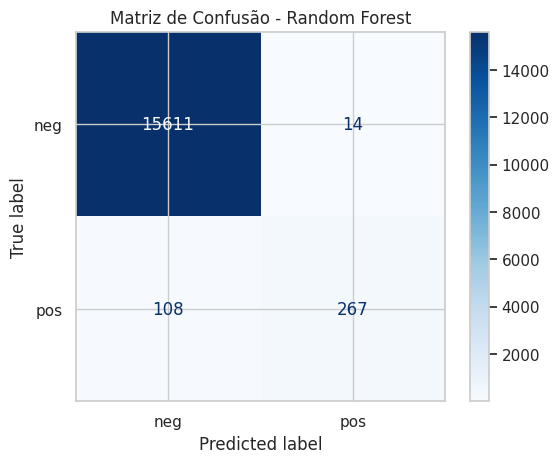

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Matriz de Confusão - Random Forest")

plt.show()

### Interpretação

> A matriz de confusão demonstra que o modelo apresentou excelente desempenho na identificação da classe majoritária (`neg`), classificando corretamente **15.611** dos **15.625** equipamentos sem falha, com apenas **14 falsos positivos**.
>
> Em relação à classe positiva (`pos`), correspondente aos equipamentos com falha, o modelo identificou corretamente **267** das **375** ocorrências, enquanto **108** falhas foram classificadas incorretamente como equipamentos sem falha (falsos negativos).
>
> Esses resultados são coerentes com as métricas obtidas anteriormente. A elevada **Precision (95,02%)** indica que, quando o modelo prevê uma falha, essa previsão é altamente confiável. Por outro lado, o **Recall (71,20%)** evidencia que parte das falhas ainda não é identificada, representando uma oportunidade de melhoria em trabalhos futuros.

## 10.4 Análise de erros e limitações

> A análise da matriz de confusão mostrou que o modelo Random Forest cometeu poucos **falsos positivos** (14 casos), indicando que, quando prevê uma falha, essa previsão é altamente confiável. Entretanto, foram observados **108 falsos negativos**, ou seja, equipamentos com falha classificados como não falha. Em aplicações de manutenção preditiva, esse tipo de erro merece atenção, pois pode resultar na não identificação de equipamentos que realmente necessitam de manutenção.
>
> Não foram observados indícios claros de **underfitting**, uma vez que o modelo apresentou desempenho superior ao Baseline e alcançou **F1-Score de 81,40%**. Da mesma forma, embora não seja possível descartar completamente a ocorrência de **overfitting**, a utilização de validação cruzada durante a otimização dos hiperparâmetros e o bom desempenho obtido no conjunto de teste indicam que o modelo apresenta capacidade satisfatória de generalização.
>
> A escolha do **F1-Score** como principal métrica mostrou-se adequada, pois o conjunto de dados apresenta forte desbalanceamento entre as classes. Diferentemente da acurácia, o F1-Score considera simultaneamente **Precision** e **Recall**, fornecendo uma avaliação mais representativa da capacidade do modelo em identificar corretamente os casos de falha.
>
> Entre as limitações do trabalho destacam-se o elevado desbalanceamento entre as classes e a presença de grande quantidade de valores ausentes em diversas variáveis. Além disso, a busca de hiperparâmetros foi realizada com uma grade reduzida, compatível com o escopo do MVP, podendo ser ampliada em estudos futuros.
>
> Dessa forma, embora o modelo tenha apresentado desempenho bastante satisfatório, sua utilização em ambientes reais deve ser acompanhada de monitoramento contínuo e reavaliações periódicas, principalmente em aplicações nas quais a não detecção de falhas possa gerar impactos operacionais ou financeiros significativos.
>
> O modelo também não deve ser utilizado como único mecanismo de decisão em cenários nos quais a detecção de todas as falhas seja crítica para a segurança ou para a operação dos equipamentos, uma vez que ainda ocorrem falsos negativos. Nesses casos, recomenda-se que as previsões do modelo sejam utilizadas como ferramenta de apoio à decisão, em conjunto com inspeções técnicas e outras estratégias de manutenção.

# 11. Comparação final dos modelos
| Modelo | F1-Score | Outras métricas | Tempo de treino | Observações |
|:--------|:--------:|:----------------|:---------------:|:------------|
| **Baseline** | **0,0000** | Accuracy = 97,66% | Muito baixo | Prevê apenas a classe majoritária (`neg`), não identificando casos de falha. |
| **Regressão Logística** | **0,7634** | Accuracy = 98,98%; Precision = 83,76%; Recall = 70,13% | Baixo | Bom desempenho e elevada interpretabilidade, porém inferior à Random Forest. |
| **Árvore de Decisão** | **0,7376** | Accuracy = 98,84%; Precision = 78,79%; Recall = 69,33% | Baixo | Modelo simples e de fácil interpretação, mas apresentou desempenho inferior aos demais modelos candidatos. |
| **Random Forest** | **0,8140** | Accuracy = 99,24%; Precision = 95,02%; Recall = 71,20% | Moderado | Melhor desempenho geral, sendo selecionado como modelo final do projeto. |

>_Os tempos de treinamento foram classificados de forma qualitativa, com base na execução observada no ambiente Google Colab, não tendo sido registrados em segundos._


# 12. Boas práticas e rastreabilidade
Nesta seção são registradas as principais decisões adotadas durante o desenvolvimento do MVP, com o objetivo de garantir a rastreabilidade dos experimentos e facilitar a reprodução dos resultados obtidos.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|:---------|:--------------|:-----------------|
| Utilização da **seed = 42** | Garantir a reprodutibilidade dos experimentos. | Permitir que os resultados possam ser reproduzidos em novas execuções. |
| Utilização do **F1-Score** como métrica principal | O conjunto de dados apresenta forte desbalanceamento entre as classes. | Avaliar o desempenho considerando simultaneamente Precision e Recall. |
| Imputação dos valores ausentes utilizando a **mediana** | A mediana é menos sensível à presença de valores extremos (outliers). | Preservar melhor a distribuição original dos dados. |
| Padronização das variáveis numéricas | As variáveis apresentam escalas bastante diferentes. | Evitar que atributos de maior magnitude influenciem excessivamente alguns modelos. |
| Manutenção das **170 variáveis preditoras** | Não foram identificadas colunas de identificação, datas ou vazamento de informação. | Preservar todas as informações disponíveis para a modelagem. |
| Utilização de um **Pipeline** | Aplicar automaticamente imputação e padronização apenas com os dados de treinamento. | Evitar vazamento de dados e aumentar a reprodutibilidade dos experimentos. |
| Comparação entre quatro modelos | Avaliar diferentes abordagens para o problema de classificação. | Selecionar o modelo com melhor desempenho. |
| Otimização da **Random Forest** utilizando GridSearchCV | Foi o modelo que apresentou o melhor desempenho na avaliação inicial. | Buscar uma configuração mais adequada dos hiperparâmetros. |
| Utilização de uma grade reduzida de hiperparâmetros | Compatibilizar o tempo de processamento com o escopo do MVP. | Demonstrar o processo de otimização mantendo baixo custo computacional. |

### Informações adicionais

- **Seed utilizada:** 42
- **Modelos avaliados:** Baseline (DummyClassifier), Regressão Logística, Árvore de Decisão e Random Forest.
- **Modelo selecionado:** Random Forest.
- **Estratégia de validação:** GridSearchCV com validação cruzada estratificada (Stratified K-Fold) utilizando 3 folds.
- **Tempo aproximado de treinamento:** muito baixo para o Baseline, baixo para a Regressão Logística e Árvore de Decisão e moderado para a Random Forest e sua etapa de otimização.
- **Recursos computacionais utilizados:** Google Colab, Python, Scikit-learn, Pandas, NumPy, Matplotlib e Seaborn.
- **Principais limitações:** forte desbalanceamento entre as classes, elevada quantidade de valores ausentes e utilização de uma grade reduzida de hiperparâmetros.
- **Alternativas não implementadas:** técnicas de reamostragem (SMOTE), ampliação da grade de hiperparâmetros e avaliação de outros algoritmos de classificação, por estarem fora do escopo deste MVP.


# 13. Conclusão

### Conclusão

> O presente MVP teve como objetivo desenvolver e avaliar modelos de Machine Learning capazes de identificar falhas no sistema APS de caminhões Scania a partir de dados provenientes de sensores operacionais. Como se trata de um problema de classificação com forte desbalanceamento entre as classes, foi adotado um fluxo completo de desenvolvimento, contemplando análise exploratória, preparação dos dados, construção de um pipeline de pré-processamento, treinamento de diferentes modelos e otimização de hiperparâmetros.
>
> Entre os modelos avaliados, a **Random Forest** apresentou o melhor desempenho geral, demonstrando maior capacidade de identificar corretamente equipamentos com ocorrência de falha. A comparação com o modelo **Baseline** evidenciou que a utilização de técnicas de Machine Learning proporcionou ganhos expressivos, mostrando que o modelo foi capaz de aprender padrões relevantes presentes nos dados, em vez de apenas prever a classe majoritária.
>
> Durante o desenvolvimento do projeto, foi possível compreender a importância de etapas que vão além do treinamento do modelo, como a análise exploratória dos dados, o tratamento adequado dos valores ausentes, a utilização de pipelines para evitar vazamento de dados, a escolha de métricas compatíveis com problemas desbalanceados e a validação por meio de busca de hiperparâmetros. Essas etapas contribuíram diretamente para a obtenção de resultados consistentes e reprodutíveis.
>
> Como limitações do trabalho, destacam-se o forte desbalanceamento entre as classes, a elevada quantidade de valores ausentes em algumas variáveis e a utilização de uma grade reduzida de hiperparâmetros, compatível com o escopo deste MVP. Além disso, o modelo ainda apresentou falsos negativos, indicando que algumas falhas não foram identificadas corretamente.
>
> Como trabalhos futuros, recomenda-se investigar técnicas adicionais para tratamento do desbalanceamento, como **SMOTE**, ampliar a busca de hiperparâmetros, avaliar outros algoritmos de classificação e explorar métodos de seleção de atributos que possam reduzir a complexidade do modelo sem comprometer seu desempenho.
>
> Em síntese, os resultados obtidos demonstram que a abordagem adotada foi capaz de atender ao objetivo proposto, evidenciando o potencial das técnicas de Machine Learning para apoiar sistemas de manutenção preditiva e contribuir para a identificação antecipada de falhas em equipamentos industriais.